###Veri temizleme


In [ ]:
import sys
import os
sys.path.append(os.path.abspath("../src"))
from data_loader import load_data
import pandas as pd

df = load_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")

def main():
    print(df.head())
    print(df.describe())

if __name__ == "__main__":
    main()

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:

print(df.info())

In [ ]:
df = load_data("../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.isnull().sum())
print(df.duplicated().sum())

In [ ]:
print(df["TotalCharges"])

In [ ]:
# TotalCharges sütununu sayısal yapıp, hata olanları NaN'a çeviriyoruz
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Null (NaN) olan satırları siliyoruz
df = df.dropna(subset=['TotalCharges_num'])

# Silinenlerden sonra kalanlarda hala null var mı kontrol edelim (opsiyonel)
print("Kalan null TotalCharges_num sayısı:", df['TotalCharges_num'].isna().sum())

Kalan null TotalCharges_num sayısı: 0


In [ ]:
# tenure değeri 0 olanların sayısını bul ve yazdır
tenure_zero_count = (df['tenure'] == 0).sum()
print(f"tenure değeri 0 olan satır sayısı: {tenure_zero_count}")

# tenure değeri 0 olan satırları sil
df = df[df['tenure'] != 0]

tenure değeri 0 olan satır sayısı: 0


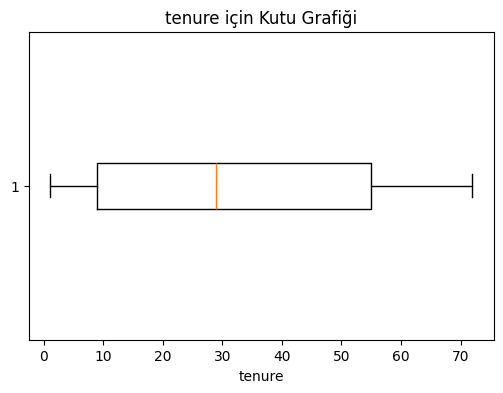

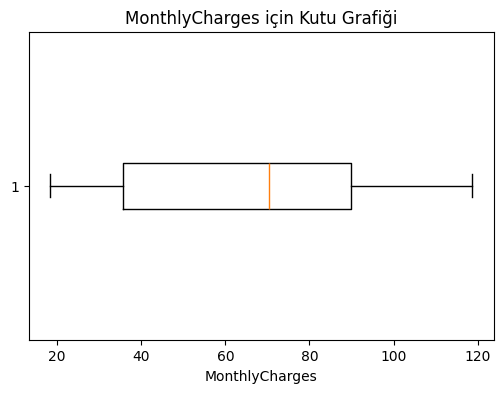

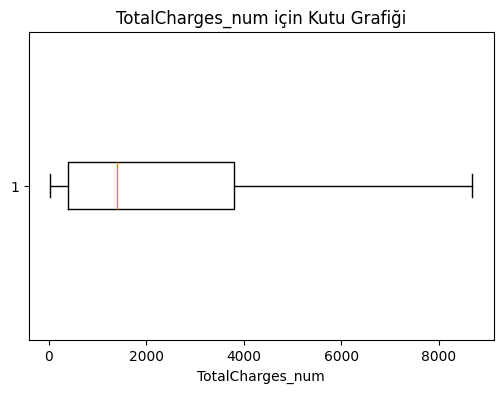

In [ ]:
# "TotalCharges" sütununu veri setinden siliyoruz
df = df.drop(columns=["TotalCharges"], errors="ignore")

import matplotlib.pyplot as plt

# SeniorCitizen'ı dahil etmeden sayısal sütunları seçelim
numeric_cols = [col for col in df.select_dtypes(include=['float64', 'int64']).columns if col != "SeniorCitizen"]

# Her sayısal değer için ayrı kutu grafiği çizelim
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"{col} için Kutu Grafiği")
    plt.xlabel(col)
    plt.show()

In [ ]:
# "Yes"/"No", "True"/"False" ve "Female"/"Male" (gender) sütunlarında label encoding: Yes/True/Female=1, No/False/Male=0
# OnlineSecurity, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, churn sütunlarını da ekle

yesno_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling", "gender",
    "OnlineSecurity", "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies", "Churn"
]

for col in yesno_cols:
    if col == "gender":
        df[col] = df[col].replace({"Female": 1, "Male": 0})
    else:
        df[col] = df[col].replace({"No": 0, "Yes": 1, "False": 0, "True": 1})

print(df[yesno_cols].head())

  Partner Dependents PhoneService PaperlessBilling gender OnlineSecurity  \
0       1          0            0                1      1              0   
1       0          0            1                0      0              1   
2       0          0            1                1      0              1   
3       0          0            0                0      0              1   
4       0          0            1                1      1              0   

  DeviceProtection TechSupport StreamingTV StreamingMovies Churn  
0                0           0           0               0     0  
1                1           0           0               0     0  
2                0           0           0               0     1  
3                1           1           0               0     0  
4                0           0           0               0     1  


In [ ]:
df['Contract'] = df['Contract'].replace({'Month-to-month': 0, 'One year': 1, 'Two year': 2})
df['MultipleLines'] = df['MultipleLines'].replace({'No': 0, 'Yes': 1, 'No phone service': 2})

print(df.head())

   customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG      1              0       1          0       1            0   
1  5575-GNVDE      0              0       0          0      34            1   
2  3668-QPYBK      0              0       0          0       2            1   
3  7795-CFOCW      0              0       0          0      45            0   
4  9237-HQITU      1              0       0          0       2            1   

  MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0             2             DSL              0  ...                0   
1             0             DSL              1  ...                1   
2             0             DSL              1  ...                0   
3             2             DSL              1  ...                1   
4             0     Fiber optic              0  ...                0   

  TechSupport StreamingTV StreamingMovies Contract PaperlessBilling  \
0           0        

In [ ]:
# InternetService ve PaymentMethod için one hot encoding yap
df = pd.get_dummies(df, columns=["InternetService", "PaymentMethod"], drop_first=False)
print(df.head())

   customerID gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG      1              0       1          0       1            0   
1  5575-GNVDE      0              0       0          0      34            1   
2  3668-QPYBK      0              0       0          0       2            1   
3  7795-CFOCW      0              0       0          0      45            0   
4  9237-HQITU      1              0       0          0       2            1   

  MultipleLines OnlineSecurity OnlineBackup  ... MonthlyCharges Churn  \
0             2              0          Yes  ...          29.85     0   
1             0              1           No  ...          56.95     0   
2             0              1          Yes  ...          53.85     1   
3             2              1           No  ...          42.30     0   
4             0              0           No  ...          70.70     1   

  TotalCharges_num InternetService_DSL InternetService_Fiber optic  \
0            29.

In [ ]:
# customerID sütununu sil
df = df.drop(columns=["customerID"])

# 1. Önce metin tabanlı sütunları temizleyelim (Replace kullanarak)
# Bu sözlük, senin "object" sütunlarındaki tüm ihtimalleri kapsamalı
cleanup_map = {
    'Yes': 1, 'No': 0, 
    'No internet service': 0, 
    'No phone service': 0,
    'Female': 1, 'Male': 0,
    'Month-to-month': 0, 'One year': 1, 'Two year': 2
}

# 2. Tüm tabloya uygula (Hala metin olanları sayı yapar)
df = df.replace(cleanup_map)

# 3. Şimdi senin döngünü daha güvenli bir şekilde çalıştıralım
for col in df.columns:
    if df[col].dtype == 'float64' or df[col].dtype == 'float32':
        df[col] = df[col].astype('float32') # Hassasiyeti koru
    else:
        # pd.to_numeric kullanarak önce sayıya zorluyoruz, 
        # sonra sığabilecekleri en küçük tipe (downcast) çekiyoruz
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
        
        # Taşma (overflow) riskine karşı paraları ve tenure'ı ayırarak int yapalım
        if col in ['tenure']:
            df[col] = df[col].astype('int16')
        elif col not in ['MonthlyCharges', 'TotalCharges_num']:
            df[col] = df[col].astype('int8')

In [ ]:
print(df.head())

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0       1              0        1           0       1             0   
1       0              0        0           0      34             1   
2       0              0        0           0       2             1   
3       0              0        0           0      45             0   
4       1              0        0           0       2             1   

   MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  ...  \
0              2               0             1                 0  ...   
1              0               1             0                 1  ...   
2              0               1             1                 0  ...   
3              2               1             0                 1  ...   
4              0               0             0                 0  ...   

   MonthlyCharges  Churn  TotalCharges_num  InternetService_DSL  \
0       29.850000      0         29.850000                    1   


In [ ]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 25 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   gender                                   7032 non-null   int8   
 1   SeniorCitizen                            7032 non-null   int8   
 2   Partner                                  7032 non-null   int8   
 3   Dependents                               7032 non-null   int8   
 4   tenure                                   7032 non-null   int16  
 5   PhoneService                             7032 non-null   int8   
 6   MultipleLines                            7032 non-null   int8   
 7   OnlineSecurity                           7032 non-null   int8   
 8   OnlineBackup                             7032 non-null   int8   
 9   DeviceProtection                         7032 non-null   int8   
 10  TechSupport                              7032 non-null   int8   

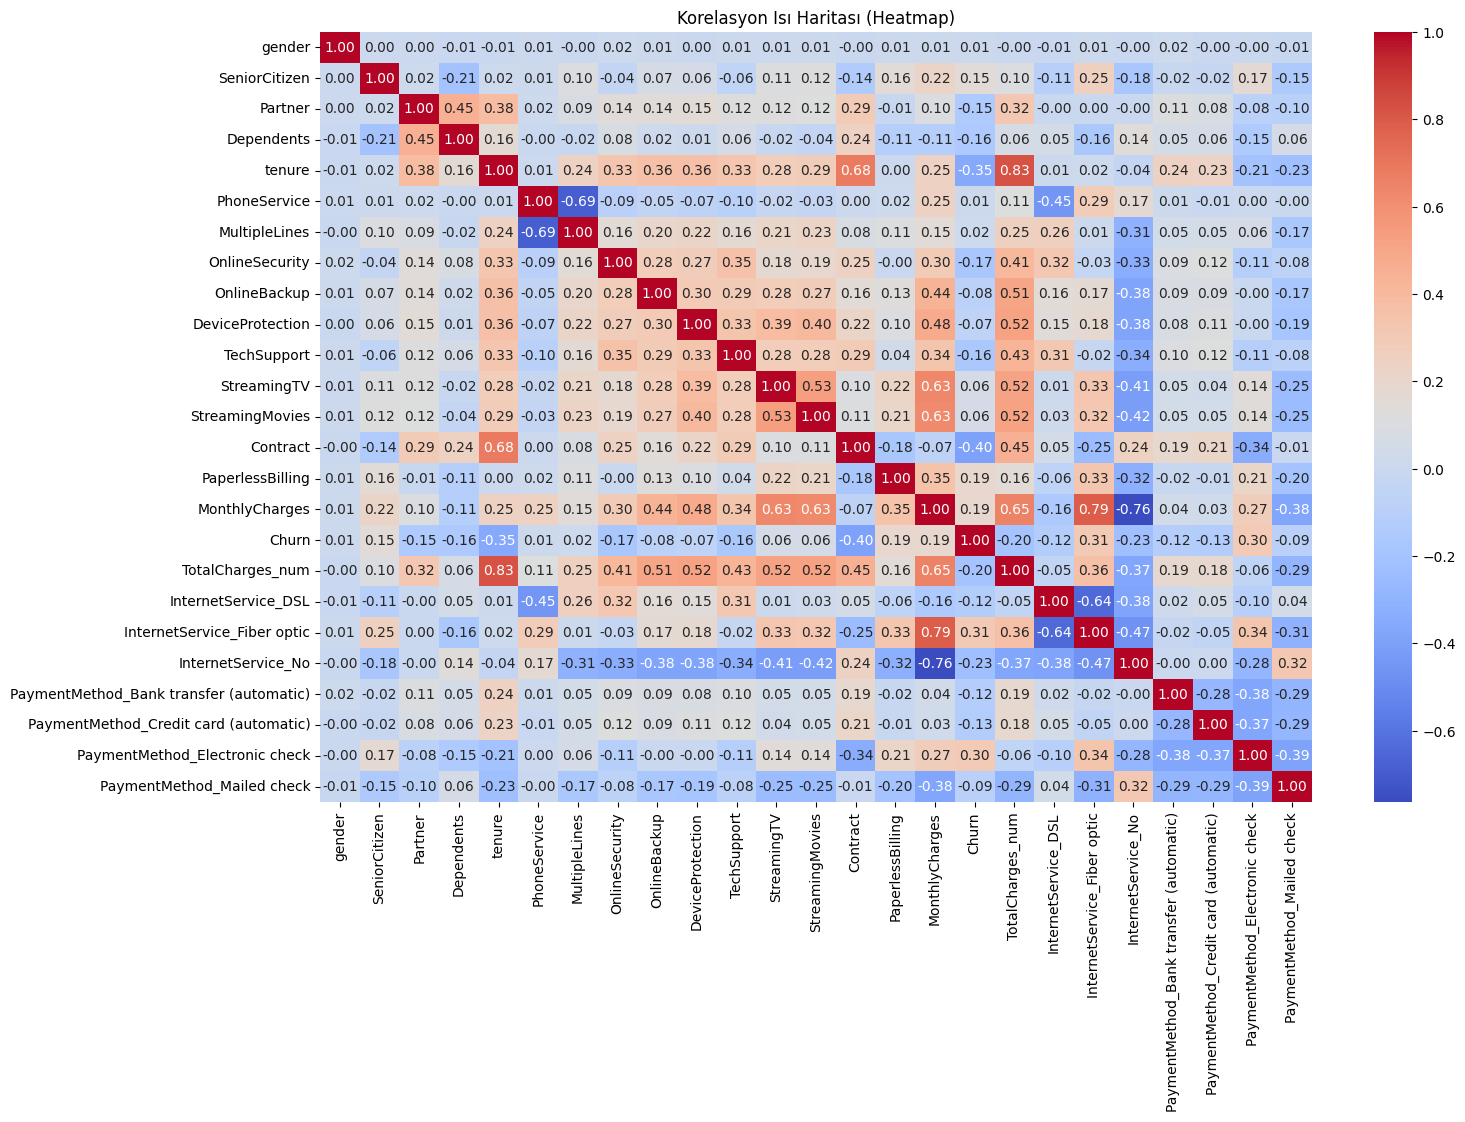

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Korelasyon Isı Haritası (Heatmap)")
plt.show()

In [ ]:
# churn ile korelasyonu 0.10'dan küçük olan sütunları sil
corrs = df.corr(numeric_only=True)
if 'Churn' in corrs.columns:
    low = corrs['Churn'].abs() < 0.10
    cols = corrs.columns[low].tolist()
    df = df.drop(cols, axis=1)

In [ ]:
# Churn hariç ikili korelasyonu 0.80'den büyük olanları yaz
corr = df.drop(columns=["Churn"], errors="ignore").corr()
for i in corr.columns:
    for j in corr.columns:
        if i != j and abs(corr.loc[i,j]) > 0.80:
            print(f"{i} - {j}: {corr.loc[i,j]:.2f}")

tenure - TotalCharges_num: 0.83
TotalCharges_num - tenure: 0.83


In [ ]:
df = df.drop(columns=["TotalCharges_num"], errors="ignore")

In [ ]:
df.info()